<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/perceptron.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)     #
# e-mail: wgomez@cinvestav.mx                   #
# Date:   february 2026                         #
# Subject:  Perceptron from scratch             #
#################################################

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Function to train a perceptron with gradient descend
def train_perceptron(X, y, tmax, eta, eps):
    n, d = X.shape # Samples by dimensions
    X = np.column_stack([np.ones(n), X]) # Add bias column (ones) to X
    y = y.reshape(-1, 1) # Ensure that y is a column vector
    t = 0 # Initialize iteration counter
    J = [] # Initialize loss array
    w = np.zeros((1, d + 1)) # Initialize weight vector
    g = np.ones((1, d + 1)) # Initialize gradient vector
    # Training loop:
    while (g @ g.T > eps) and (t < tmax):
        t = t + 1
        # Compute gradient
        g = -np.mean((y - X @ w.T) * X, axis=0, keepdims=True)
        # Update weights
        w = w - eta * g
        # Compute and store loss (mean squared error)
        J.append(np.mean((y - X @ w.T) ** 2))
    # Convert J list to numpy array
    J = np.array(J)
    return w, J

In [ ]:
# Read CSV file with breast tumor morphological features
url='https://drive.google.com/file/d/10tilQVjF71MoVGqqM0ATZ8Q6KuwsoWZr/view?usp=drive_link'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url)
# Get data arrays
arr = df.to_numpy()
X = arr[:, :-2] # Features
Y = arr[:, -2]  # Targets

In [ ]:
# Split data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2, stratify=Y)

# Normalize training data and apply same transformation to test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train perceptron
tmax = 10000 # Maximum number of iterations
eta = 1e-2 # Learning rate
eps = 1e-4 # Stopping criterion
w, J = train_perceptron(X_train, Y_train, tmax, eta, eps)

# Make predictions
nt = X_test.shape[0]
Y_scores = np.column_stack([np.ones(nt), X_test]) @ w.T # Classifcation scores
Y_pred = Y_scores >= 0.5 # Predicted class labels

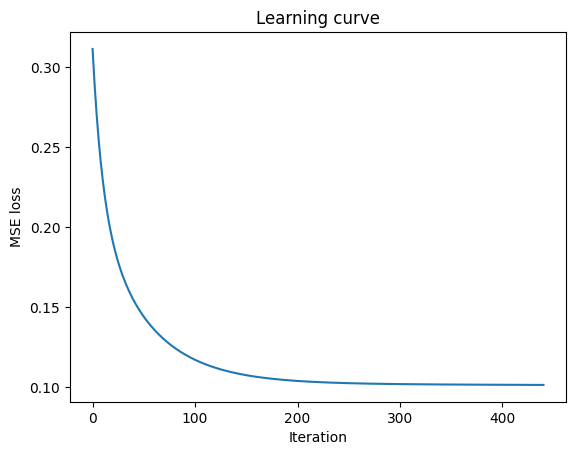


Accuracy: 0.856 

Sensitivity: 0.678 

Specificity: 0.941 



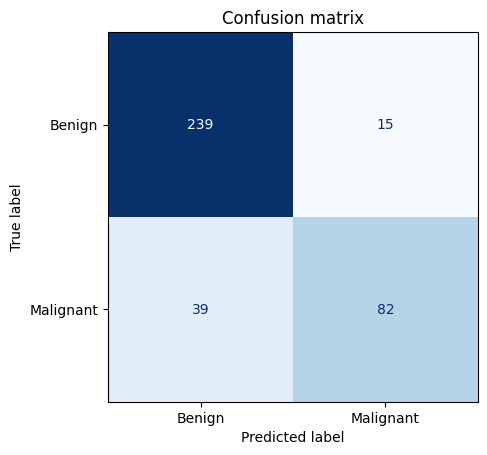

In [ ]:
# Learning curve
plt.figure()
plt.plot(np.arange(0, len(J)), J)
plt.xlabel('Iteration')
plt.ylabel('MSE loss')
plt.title('Learning curve')
plt.show()
print()

# Performance indices
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()
acc = (tp + tn) / (tp + tn + fp + fn)
sen = tp / (tp + fn)
spe = tn / (tn + fp)
print(f"Accuracy: {acc:.3f} \n")
print(f"Sensitivity: {sen:.3f} \n")
print(f"Specificity: {spe:.3f} \n")

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()